In [11]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer


In [4]:
df = pd.read_csv("concrete_data.csv")
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
560,220.8,147.2,0.0,185.7,0.0,1055.0,744.3,28,25.75
345,213.7,0.0,174.7,154.8,10.2,1053.5,776.4,14,33.73
251,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
750,500.0,0.0,0.0,200.0,0.0,1125.0,613.0,28,44.09
917,148.0,175.0,0.0,171.0,2.0,1000.0,828.0,28,26.92


In [9]:
x = df.drop(columns=["Strength"])
y= df.iloc[:,-1]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3
...,...,...,...,...,...,...,...,...
87,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,3
330,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,14
466,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,100
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28


In [12]:
lr=LinearRegression()

lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


0.6275531792314848

In [14]:
lr=LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring="r2"))

/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encount

np.float64(0.4609940491662866)

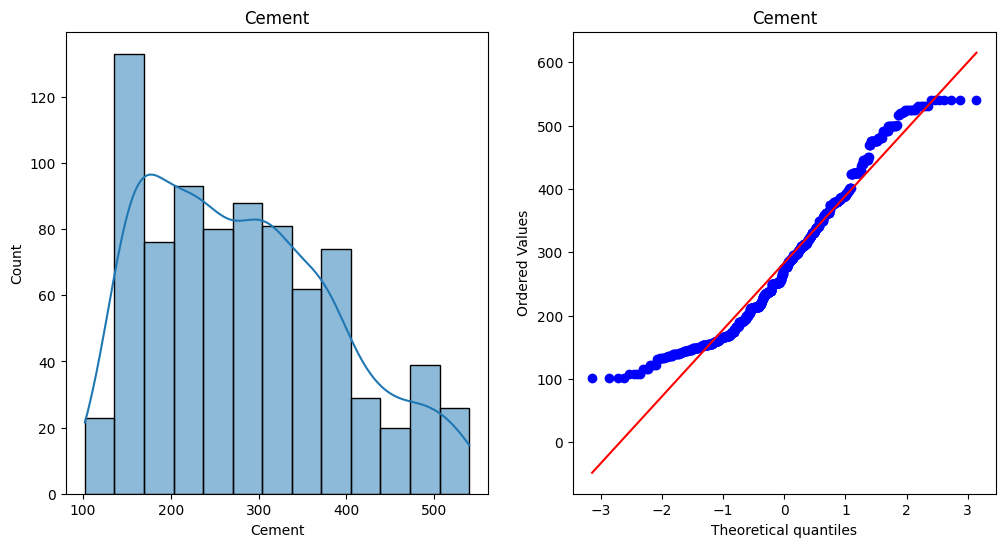

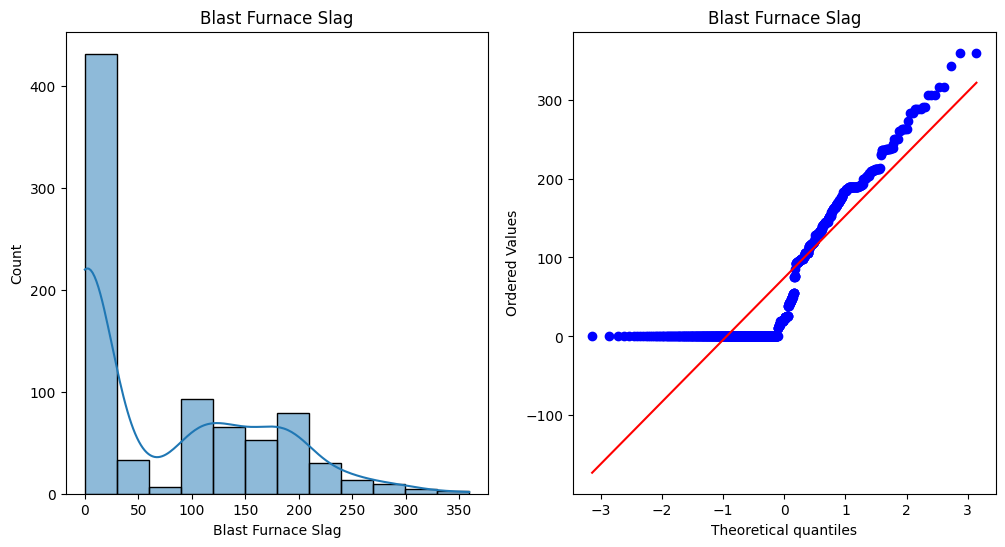

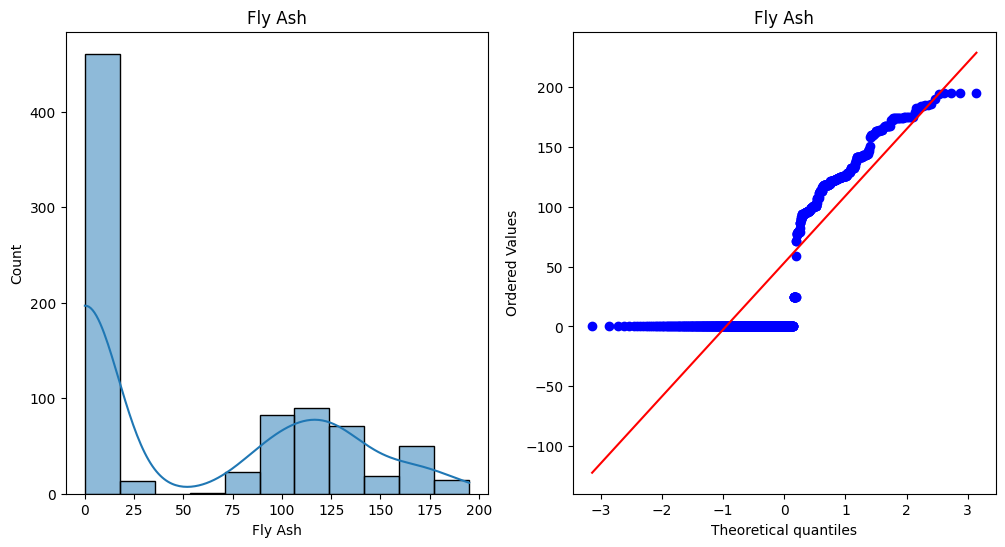

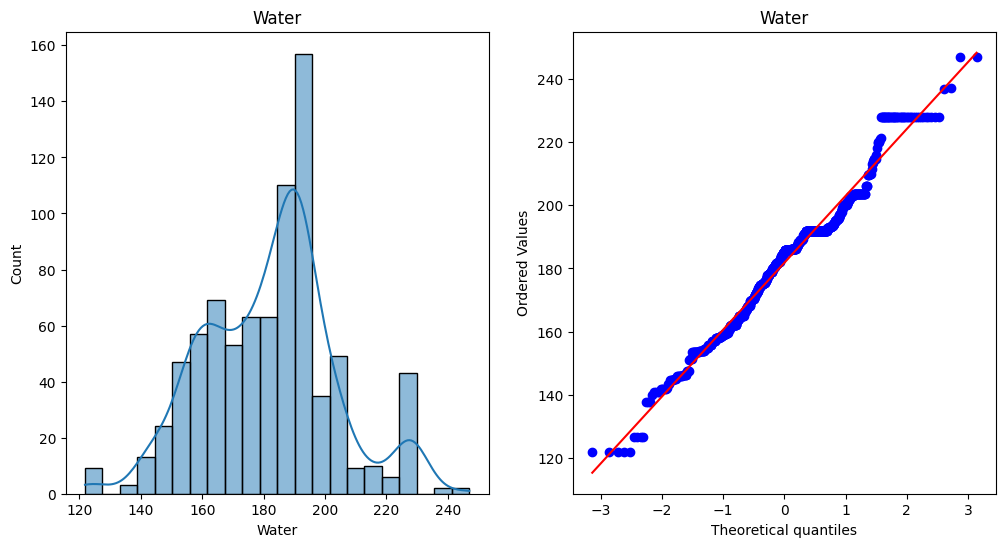

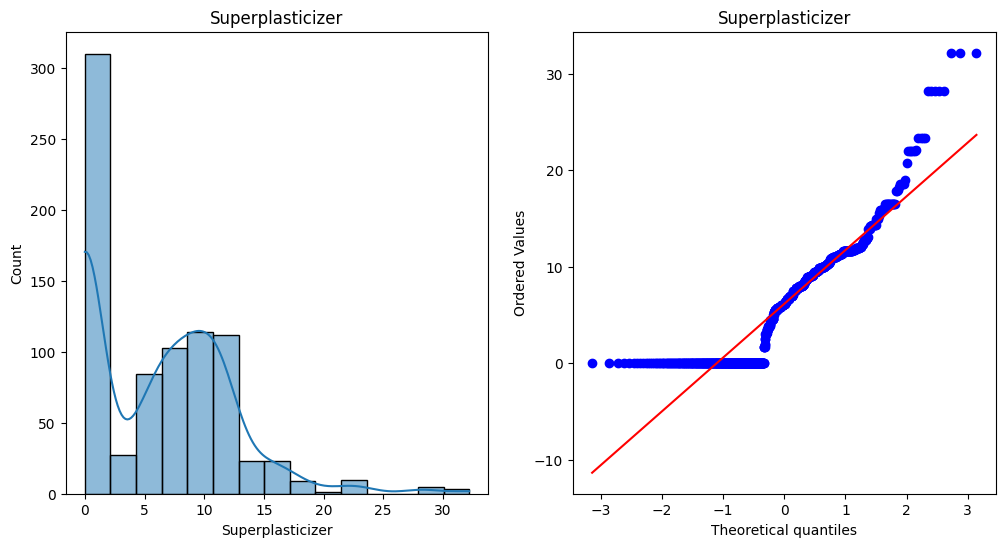

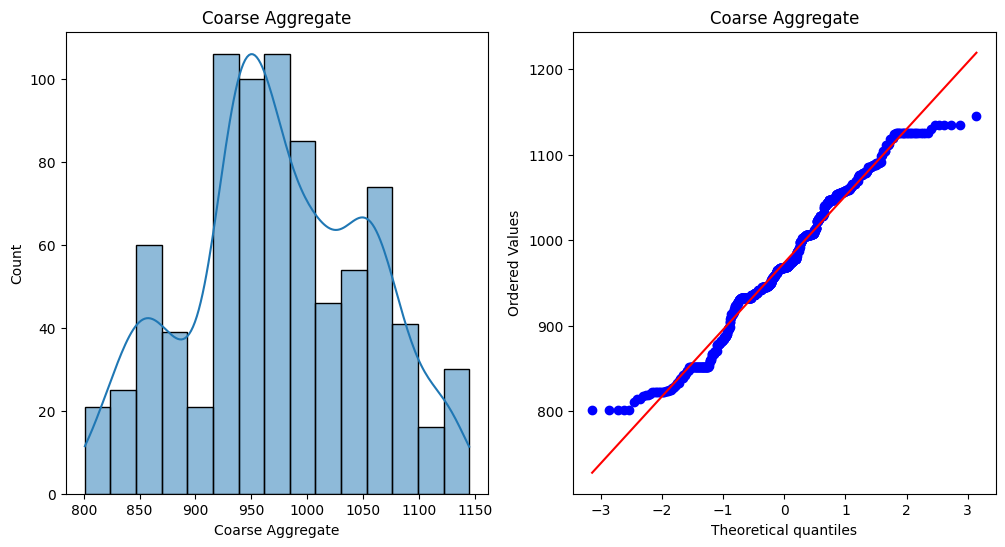

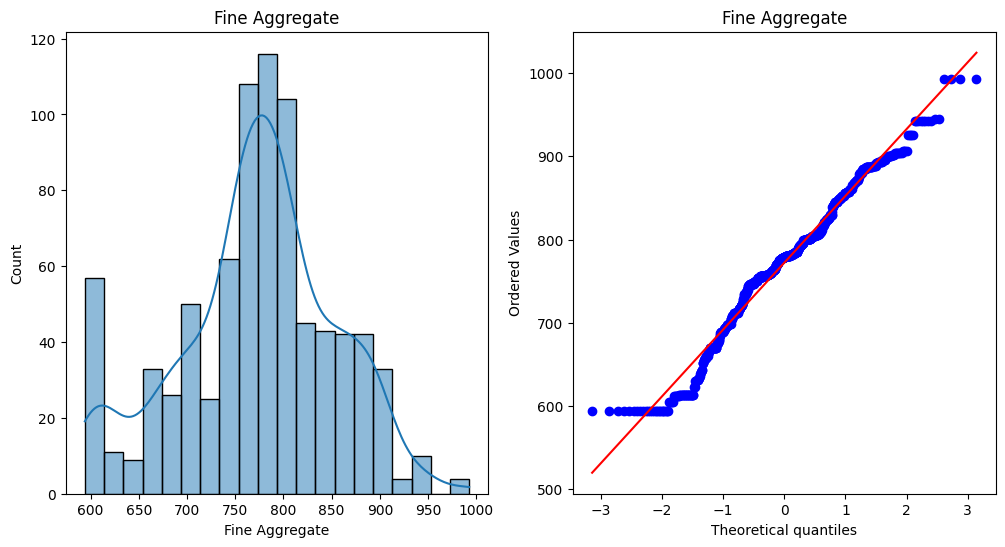

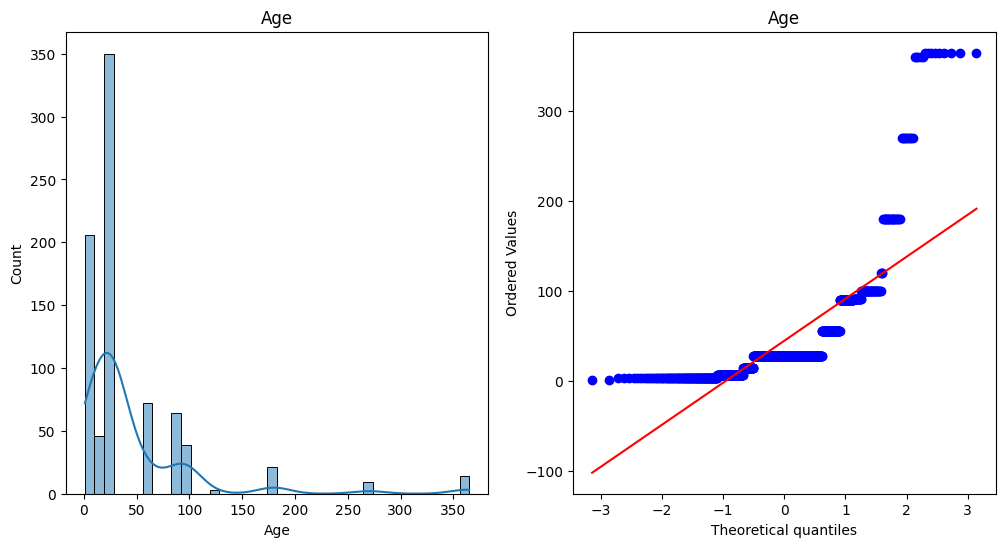

In [16]:
for col in x_train.columns:
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()


In [17]:
pt = PowerTransformer(method="box-cox")

x_train_transformed = pt.fit_transform(x_train + 0.000001)
x_test_transformed = pt.fit_transform(x_test + 0.000001)


pd.DataFrame({"cols":x_train.columns, "box_cox_lambdas":pt.lambdas_})


,cols,box_cox_lambdas
0,Cement,0.215602
1,Blast Furnace Slag,0.025996
2,Fly Ash,-0.006544
3,Water,0.959062
4,Superplasticizer,0.103365
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [18]:
lr=LinearRegression()

lr.fit(x_train_transformed,y_train)
y_pred=lr.predict(x_test_transformed)
r2_score(y_test,y_pred)

/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


0.8055321002033324

In [21]:
pt = PowerTransformer()
x_transformed = pt.fit_transform(x + 1e-7)  # Add small value to avoid log(0)

# Model
lr = LinearRegression()

# Cross-validation with r2 score
mean_r2 = np.mean(cross_val_score(lr, x_transformed, y, scoring="r2"))
print(mean_r2)

0.6834625137913093


/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encount

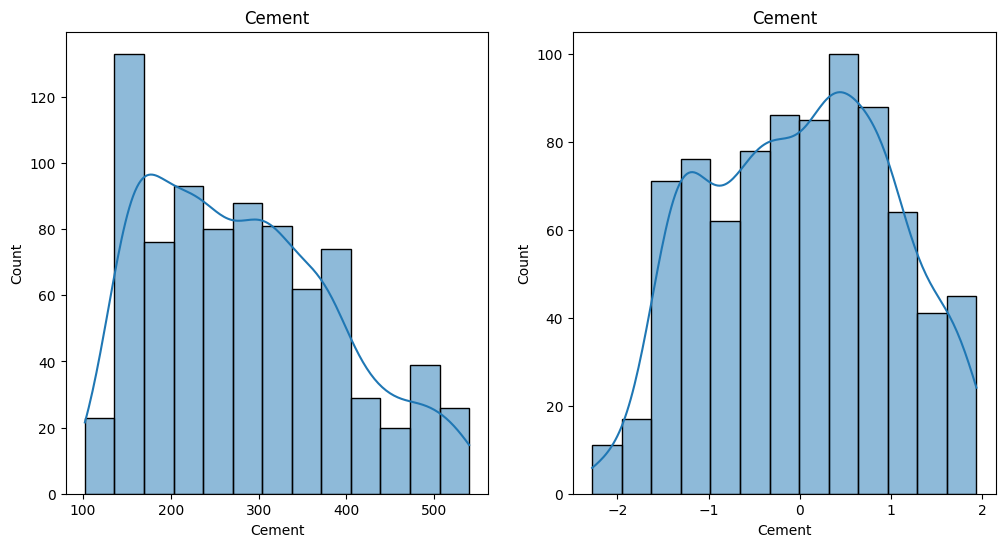

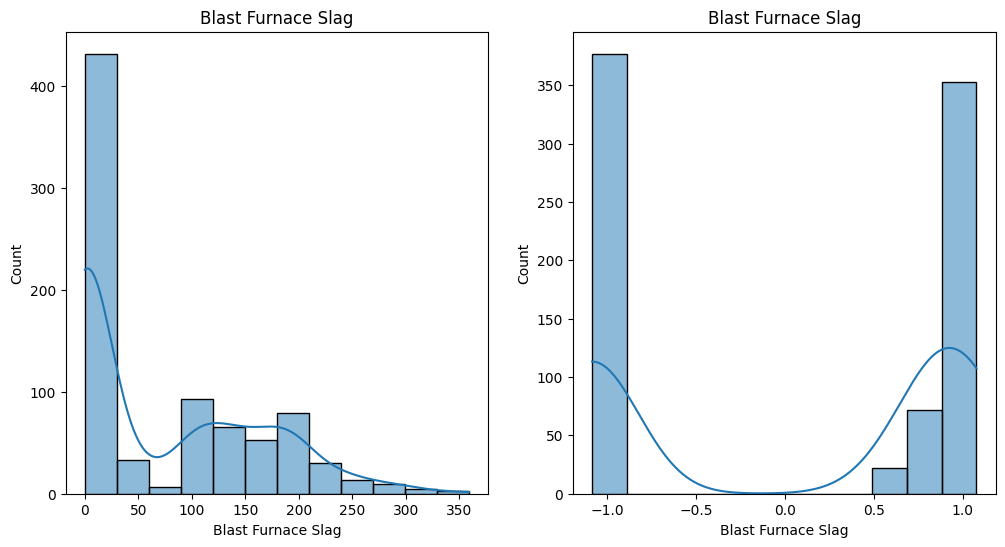

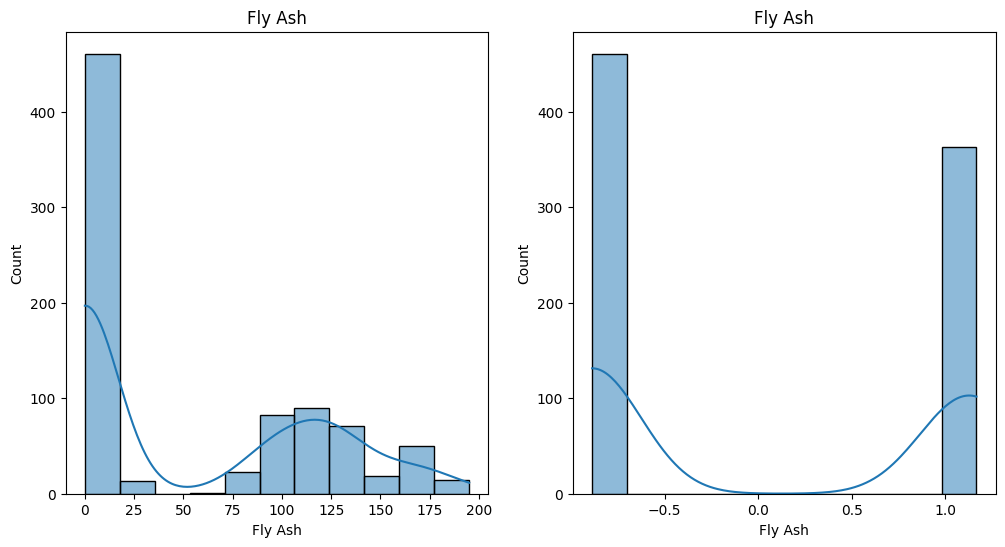

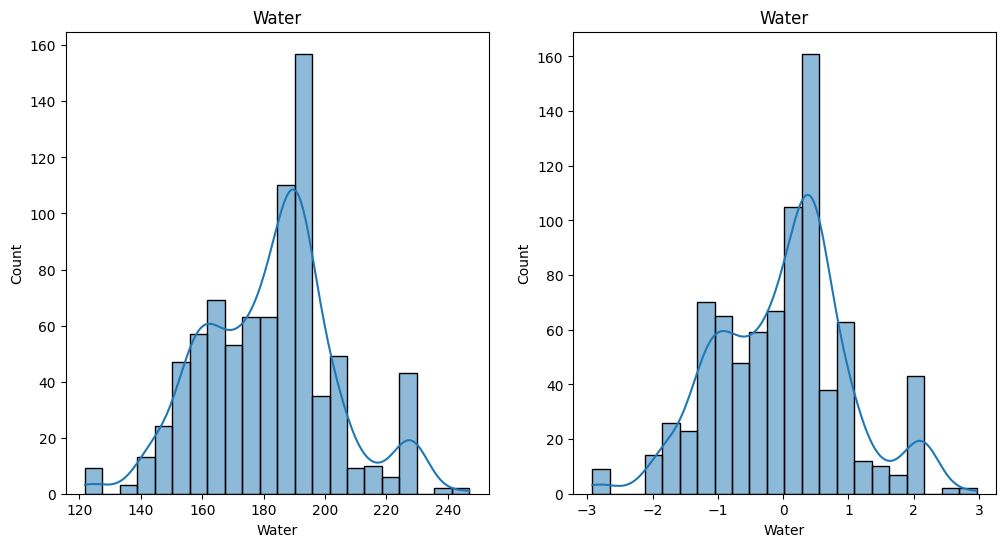

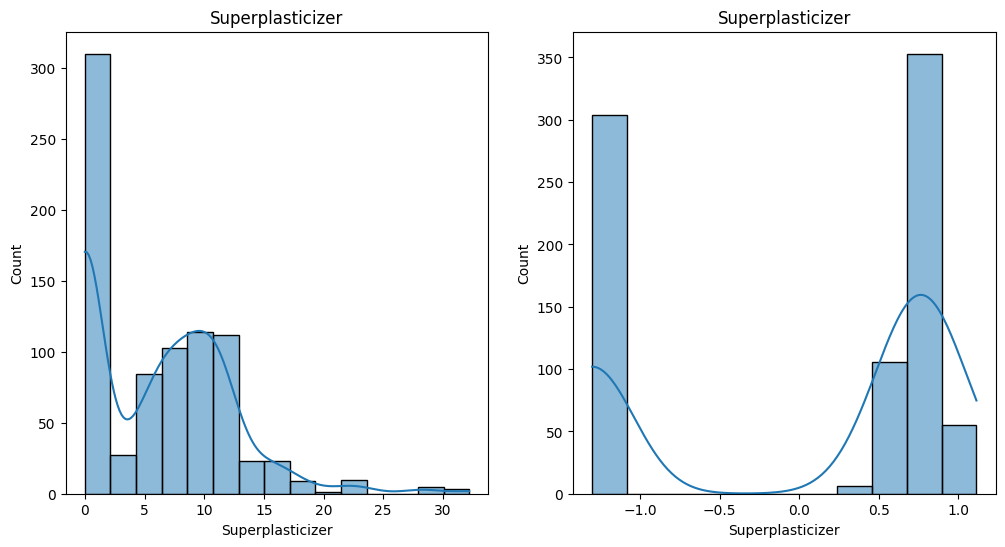

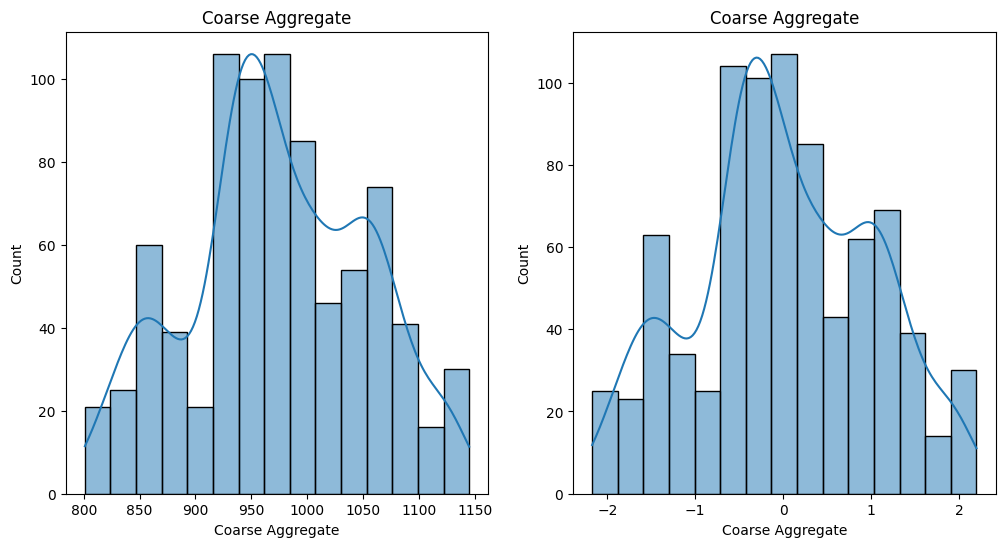

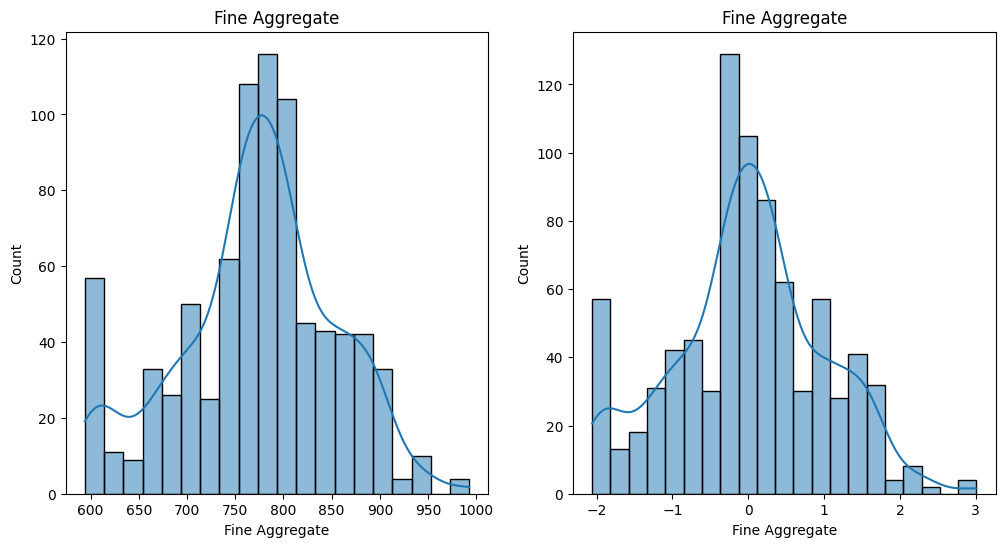

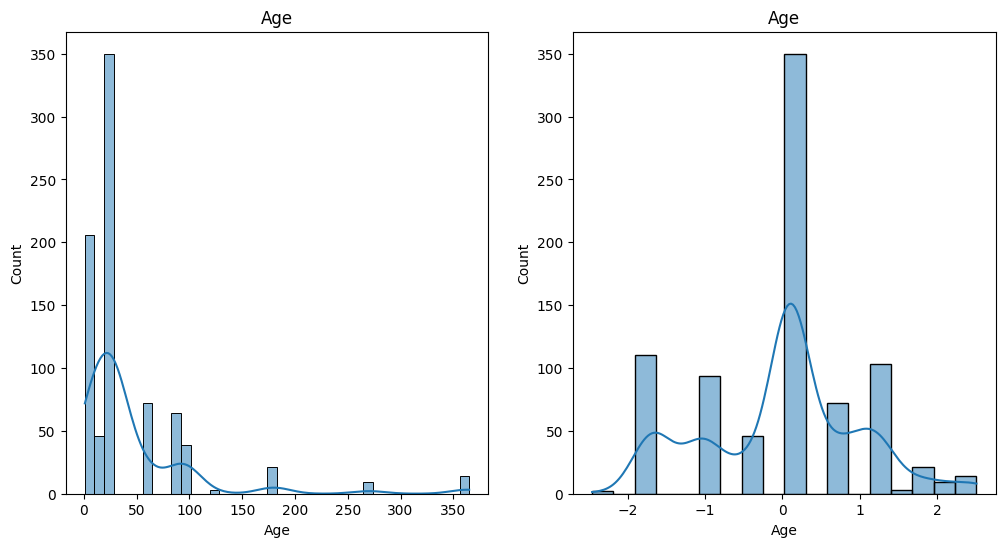

In [25]:
x_train_transformed = pd.DataFrame(x_train_transformed,columns=x_train.columns)
for col in x_train_transformed.columns:
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    sns.histplot(x_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_transformed[col],kde=True)
    plt.title(col)

    plt.show()